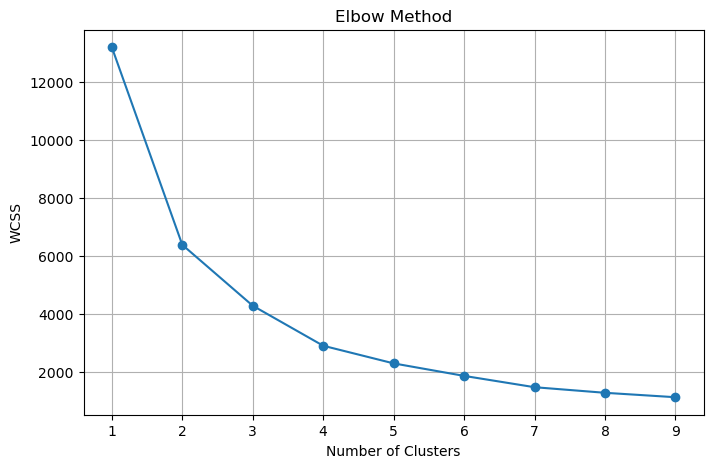

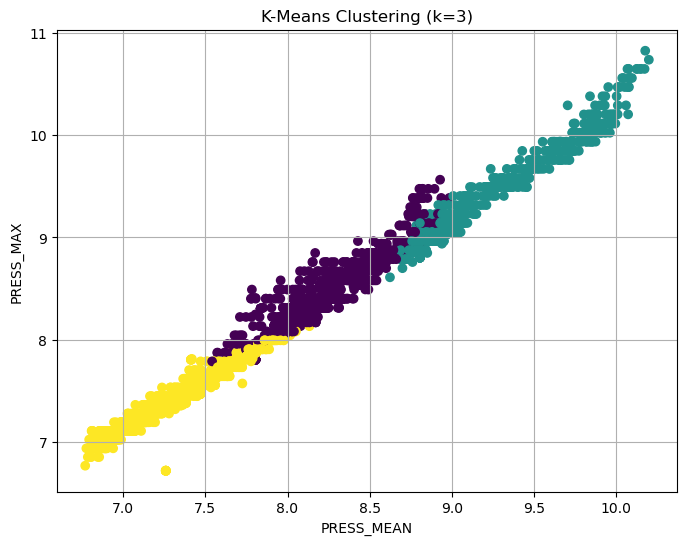

Cluster Centers:
   press_mean  press_max  press_min  press_range
0    8.237903   8.438154   8.002786     0.435368
1    9.265187   9.443663   9.086722     0.356941
2    7.269123   7.376735   7.142539     0.239818

Cluster Counts:
cluster
0    1314
2    1164
1     819
Name: count, dtype: int64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("C:/Users/prabh/Documents/Mars_Dataset/Mars_DataSet_v1.csv")

# Clean
df.columns = df.columns.str.strip().str.lower()
df = df.replace(-9.999, np.nan)

# Select features
features = ['press_mean', 'press_max', 'press_min', 'press_range']
df_cluster = df[features].dropna()

# Scale data (VERY IMPORTANT for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# -----------------------------------
# Find optimal clusters (Elbow Method)
# -----------------------------------
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# -----------------------------------
# Apply KMeans (choose k=3)
# -----------------------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# -----------------------------------
# Visualization
# -----------------------------------
plt.figure(figsize=(8,6))
plt.scatter(df_cluster['press_mean'], df_cluster['press_max'],
            c=df_cluster['cluster'])

plt.xlabel("PRESS_MEAN")
plt.ylabel("PRESS_MAX")
plt.title("K-Means Clustering (k=3)")
plt.grid(True)
plt.show()

# -----------------------------------
# Cluster centers
# -----------------------------------
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=features)

print("Cluster Centers:")
print(centers_df)

# -----------------------------------
# Cluster distribution
# -----------------------------------
print("\nCluster Counts:")
print(df_cluster['cluster'].value_counts())

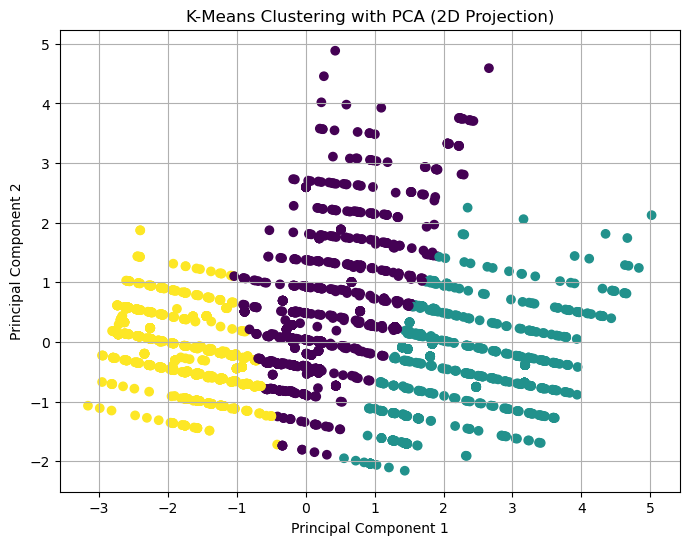

Explained Variance Ratio:
PC1: 0.7712
PC2: 0.2281
Total Variance Explained: 0.9994

Cluster Centers:
   press_mean  press_max  press_min  press_range
0    8.237903   8.438154   8.002786     0.435368
1    9.265187   9.443663   9.086722     0.356941
2    7.269123   7.376735   7.142539     0.239818

Cluster Distribution:
cluster
0    1314
2    1164
1     819
Name: count, dtype: int64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv("C:/Users/prabh/Documents/Mars_Dataset/Mars_DataSet_v1.csv")

# Clean
df.columns = df.columns.str.strip().str.lower()
df = df.replace(-9.999, np.nan)

# Select features
features = ['press_mean', 'press_max', 'press_min', 'press_range']
df_cluster = df[features].dropna()

# -----------------------------------
# 1. Scaling
# -----------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

# -----------------------------------
# 2. KMeans clustering
# -----------------------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_cluster['cluster'] = clusters

# -----------------------------------
# 3. PCA (2D Projection)
# -----------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA components
df_cluster['PC1'] = X_pca[:, 0]
df_cluster['PC2'] = X_pca[:, 1]

# -----------------------------------
# 4. PCA Visualization
# -----------------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    df_cluster['PC1'],
    df_cluster['PC2'],
    c=df_cluster['cluster']
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering with PCA (2D Projection)")
plt.grid(True)
plt.show()

# -----------------------------------
# 5. Explained Variance
# -----------------------------------
print("Explained Variance Ratio:")
print("PC1:", round(pca.explained_variance_ratio_[0], 4))
print("PC2:", round(pca.explained_variance_ratio_[1], 4))
print("Total Variance Explained:", round(sum(pca.explained_variance_ratio_), 4))

# -----------------------------------
# 6. Cluster Centers (original scale)
# -----------------------------------
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=features)

print("\nCluster Centers:")
print(centers_df)

# -----------------------------------
# 7. Cluster Counts
# -----------------------------------
print("\nCluster Distribution:")
print(df_cluster['cluster'].value_counts())